<a href="https://colab.research.google.com/github/b-karapet/colab-notebooks/blob/main/Local_Feature_Matching_with_Transformers_(LoFTR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kornia  kornia-rs  kornia_moons opencv-python --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 44.7 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/kornia/io/io.py:179: DeprecationWarning: kornia_rs.read_image_any is deprecated. Use kornia_rs.io.read_image instead.
  image: torch.Tensor = _load_image_to_tensor(path_file, device)  # CxHxW
/tmp/ipykernel_1568/1516296512.py:45: DeprecationWarning: Since kornia 0.8.3 the `tensor_to_image` is deprecated in favor of `kornia.image.tensor_to_image`.
  K.tensor_to_image(img1),
/tmp/ipykernel_1568/1516296512.py:46: DeprecationWarning: Since kornia 0.8.3 the `tensor_to_image` is deprecated in favor of `kornia.image.tensor_to_image`.
  K.tensor_to_image(img2),
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


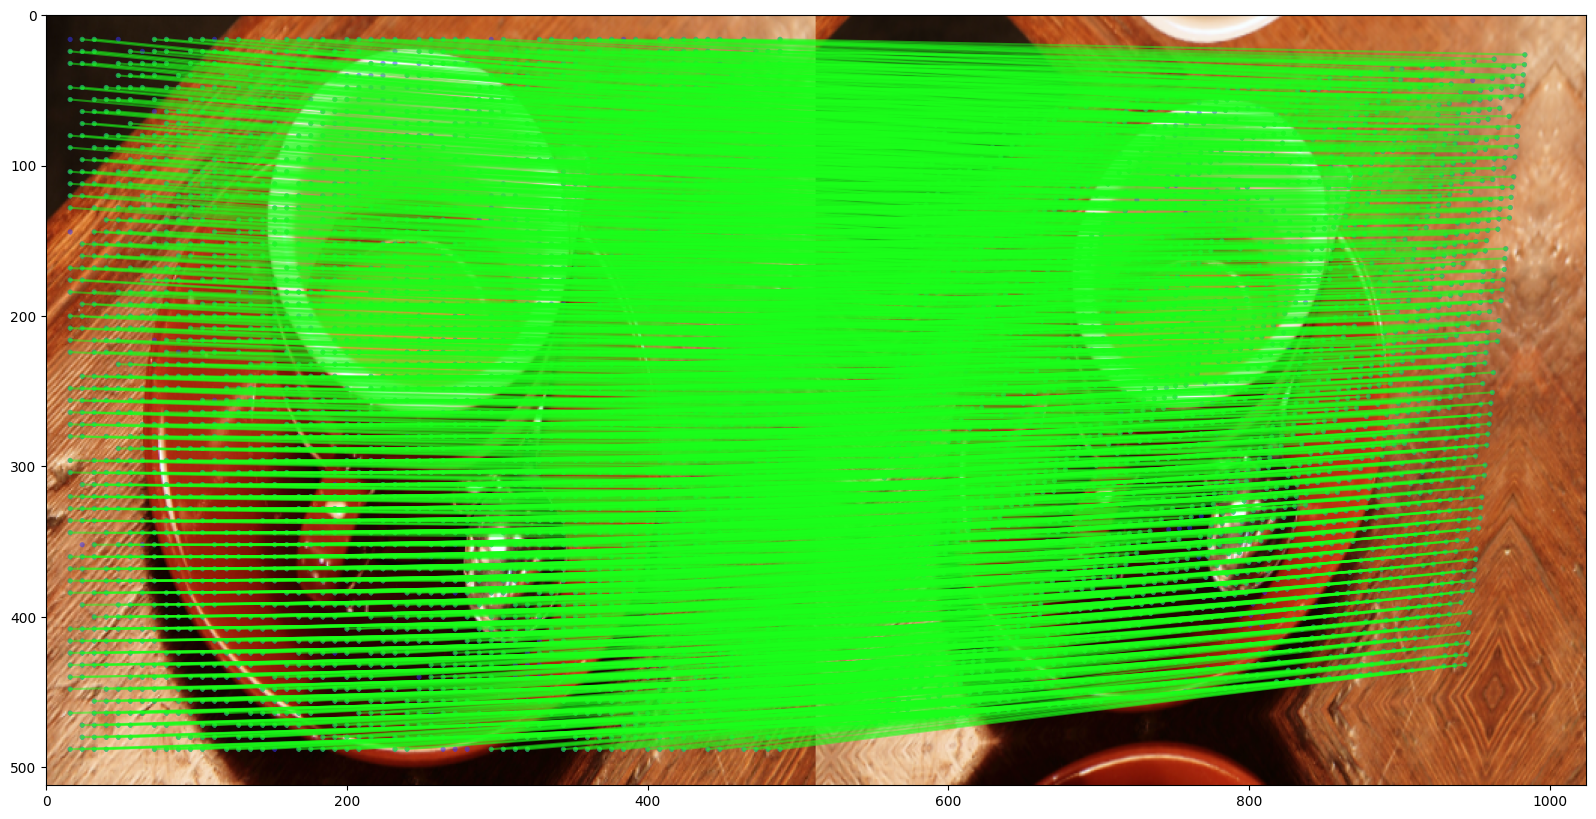

In [4]:
import cv2
import kornia as K
import kornia.feature as KF
import matplotlib.pyplot as plt
import numpy as np
import torch
from kornia_moons.viz import draw_LAF_matches
import matplotlib.pyplot as plt

from kornia.feature import LoFTR

img1 = K.io.load_image("sample_data/img3.png", K.io.ImageLoadType.RGB32)[None, ...]
img2 = K.io.load_image("sample_data/img4.png", K.io.ImageLoadType.RGB32)[None, ...]

img1 = K.geometry.resize(img1, (512, 512), antialias=True)
img2 = K.geometry.resize(img2, (512, 512), antialias=True)

matcher = LoFTR(pretrained="outdoor")

input_dict = {
    "image0": K.color.rgb_to_grayscale(img1),
    "image1": K.color.rgb_to_grayscale(img2),
}

with torch.inference_mode():
    correspondences = matcher(input_dict)

mkpts0 = correspondences["keypoints0"].cpu().numpy()
mkpts1 = correspondences["keypoints1"].cpu().numpy()
Fm, inliers = cv2.findFundamentalMat(mkpts0, mkpts1, cv2.USAC_MAGSAC, 0.5, 0.999, 100000)
inliers = inliers > 0

draw_LAF_matches(
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts0).view(1, -1, 2),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1),
    ),
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts1).view(1, -1, 2),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1),
    ),
    torch.arange(mkpts0.shape[0]).view(-1, 1).repeat(1, 2),
    K.tensor_to_image(img1),
    K.tensor_to_image(img2),
    inliers,
    draw_dict={
        "inlier_color": (0.1, 1, 0.1, 0.5),
        "tentative_color": None,
        "feature_color": (0.2, 0.2, 1, 0.5),
        "vertical": False,
    },
)